# Coffee Bean Roast Level Classification - Model Evaluation on Roast Consistency and Custom Image Predictions

This notebook does two tasks: first, uses the RF model to assess batch roast consistency; second, loads custom coffee bean images (from `coffee_data/custom_test_images/`), preprocesses them (resize to 224x224, background removal), extracts the same features used in training, and evaluates the saved Random Forest model by comparing predictions to the labels in `custom_image_labels.csv`.

In [1]:
import pandas as pd
import numpy as np
import cv2
from pathlib import Path
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import joblib

# Custom functions
from coffee_utils import load_image, remove_background, extract_features

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Assume notebook is run from the Code directory
BASE_PATH = Path("coffee_data")
CUSTOM_IMAGES_DIR = BASE_PATH / "custom_test_images"
LABELS_CSV = CUSTOM_IMAGES_DIR / "custom_image_labels.csv"
TARGET_SIZE = (224, 224)

# Saved model artifacts (produced by coffee_ML_model.ipynb)
MODEL_PATH = Path("coffee_rf_model.joblib")
SCALER_PATH = Path("coffee_scaler.joblib")
METADATA_PATH = Path("coffee_metadata.joblib")

rf = joblib.load(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)
meta = joblib.load(METADATA_PATH)
le = meta["le"]
ORDER = meta["order"]

## Batch Roast Consistency

Let's assess how well the model reflects batch-level consistency by constructing three synthetic batches from the roast-level folders (Green, Light, Medium, Dark):

- **Perfect batch:** 100 random images from a single roast folder (e.g. Light). Intended label = that roast. We expect high consistency (% predicted as intended).
- **Good batch:** 80 images from one roast (e.g. Medium) and 20 from adjacent roasts (e.g. 10 Light, 10 Dark). Intended label = the majority roast (Medium). We expect moderate consistency.
- **Bad batch:** 100 random images from all roast levels (mixed). Intended label = the plurality (most common) true label in the sample. We expect low consistency.

Images here are from the same roast-level folders used for training and are already preprocessed. We match the ML pipeline: **load** and **extract features** only (no resize, no second background removal).

**Batch consistency** = percent of beans in the batch that are predicted to be the same as the batch’s intended roast level.

In [3]:
# Collect image paths per roast folder (same structure as training data)
roast_folders = {roast: BASE_PATH / roast for roast in ORDER}
images_by_roast = {}
for roast in ORDER:
    folder = roast_folders[roast]
    if not folder.exists():
        raise FileNotFoundError(f"Roast folder not found: {folder}")
    paths = sorted(folder.glob("*.png"))
    images_by_roast[roast] = [str(p) for p in paths]

# Perfect batch: 100 from one roast
perfect_roast = "Light"
pool = images_by_roast[perfect_roast]
n_perfect = min(100, len(pool))
perfect_paths = list(np.random.choice(pool, size = n_perfect, replace = False))
perfect_true = [perfect_roast] * n_perfect
intended_perfect = perfect_roast

# Good batch: 80 from Medium, 10 from Light, 10 from Dark; intended = Medium
good_roast = "Medium"
adjacent = ["Light", "Dark"]  # adjacent to Medium
n_majority, n_adjacent_each = 80, 10
pool_majority = images_by_roast[good_roast]
pool_light = images_by_roast["Light"]
pool_dark = images_by_roast["Dark"]

good_paths = (
    list(np.random.choice(pool_majority, size = min(n_majority, len(pool_majority)), replace = False))
    + list(np.random.choice(pool_light, size = min(n_adjacent_each, len(pool_light)), replace = False))
    + list(np.random.choice(pool_dark, size = min(n_adjacent_each, len(pool_dark)), replace = False))
)

# True label = folder name for each path (robust if pool sizes are smaller than requested)
good_true = [Path(p).parent.name for p in good_paths]
intended_good = good_roast

# Bad batch: random number from each roast that sum to 100; majority class is true label
n_total_bad = 100
n_per_roast = np.random.multinomial(n_total_bad, [1 / len(ORDER)] * len(ORDER))  # random counts summing to 100
bad_paths, bad_true = [], []
for i, roast in enumerate(ORDER):
    pool = images_by_roast[roast]
    k = min(n_per_roast[i], len(pool))
    chosen = np.random.choice(pool, size=k, replace=False)
    bad_paths.extend(chosen.tolist())
    bad_true.extend([roast] * k)

# True label = most common true label in the batch
intended_bad = Counter(bad_true).most_common(1)[0][0]

In [4]:
# Run model on all batch images and compute consistency
# Batch images are from coffee_data/Light, etc. Same as training, already processed
def predict_batch(paths, scaler, rf, le, order, target_size = (224, 224), from_processed_dataset = True):
    """Load, optionally preprocess, extract features, scale, predict.
    If from_processed_dataset = True (batch from roast folders): load + extract_features only.
    If False (custom images): load + resize + remove_background + extract_features."""
    X = []

    for p in paths:
        img = load_image(p)
        if not from_processed_dataset:
            img = cv2.resize(img, target_size)
            img = remove_background(img)
        feat = extract_features(img)
        X.append(feat)
    
    X = np.array(X)
    X_scaled = scaler.transform(X)
    pred_enc = rf.predict(X_scaled)
    
    return le.inverse_transform(pred_enc)

def batch_consistency(pred_labels, intended_label):
    """Percent of predictions that match the intended batch label."""
    return 100 * (np.array(pred_labels) == intended_label).mean()

batches = [
    ("Perfect (100 from Light)", perfect_paths, perfect_true, intended_perfect),
    ("Good (80 Medium + 20 adjacent)", good_paths, good_true, intended_good),
    ("Bad (random mix, 100 total)", bad_paths, bad_true, intended_bad),
]

results = []

for name, paths, true_labels, intended in batches:
    preds = predict_batch(paths, scaler, rf, le, ORDER, TARGET_SIZE)
    consistency = batch_consistency(preds, intended)
    n = len(paths)
    
    results.append({
        "Batch": name,
        "Intended roast": intended,
        "N beans": n,
        "Consistency (% predicted as intended)": round(consistency, 1),
    })
    
    print(f"{name}")
    print(f"  Intended: {intended}  |  N = {n}  |  Consistency = {consistency:.1f}%")
    print()

print("Summary table:")
print(pd.DataFrame(results).to_string(index = False))

Perfect (100 from Light)
  Intended: Light  |  N = 100  |  Consistency = 100.0%

Good (80 Medium + 20 adjacent)
  Intended: Medium  |  N = 100  |  Consistency = 81.0%

Bad (random mix, 100 total)
  Intended: Medium  |  N = 100  |  Consistency = 28.0%

Summary table:
                         Batch Intended roast  N beans  Consistency (% predicted as intended)
      Perfect (100 from Light)          Light      100                                  100.0
Good (80 Medium + 20 adjacent)         Medium      100                                   81.0
   Bad (random mix, 100 total)         Medium      100                                   28.0


## Predictions on Custom Images

### Load and Preprocess

Load `custom_image_labels.csv` (columns: `image_filename`, `label`). The CSV may contain **any subset** of roast levels (for example, only Medium and Dark, if that's all you have). 

For each image: load, resize to 224x224, remove background (same pipeline as training data), then extract features. Order is preserved so indices align with the CSV rows.

In [5]:
labels_df = pd.read_csv(LABELS_CSV)
if "image_filename" not in labels_df.columns or "label" not in labels_df.columns:
    raise ValueError("CSV must have columns 'image_filename' and 'label'")

X_custom = []
paths_custom = []
custom_actual = []

for i in range(len(labels_df)):
    row = labels_df.iloc[i]
    fname = row["image_filename"]
    label = row["label"]
    img_path = CUSTOM_IMAGES_DIR / fname
    if not img_path.exists():
        raise FileNotFoundError(f"Image not found: {img_path}")
    img = load_image(img_path)
    img = cv2.resize(img, TARGET_SIZE)
    img = remove_background(img)
    feat = extract_features(img)
    X_custom.append(feat)
    paths_custom.append(str(img_path))
    custom_actual.append(label)

X_custom = np.array(X_custom)

labels_present = sorted(set(custom_actual))

print(f"Loaded {len(X_custom)} custom images. Feature shape: {X_custom.shape}")
print(f"Roast levels in custom set: {labels_present}")
print("Label distribution:", pd.Series(custom_actual).value_counts().sort_index().to_dict())

Loaded 20 custom images. Feature shape: (20, 15)
Roast levels in custom set: ['Dark', 'Medium']
Label distribution: {'Dark': 10, 'Medium': 10}


### Make Predictions

Scale the custom features and predict. Encode actual labels with the same encoder so indices stay aligned.

In [6]:
# Ensure all custom labels are valid (subset of trained classes)
bad = set(custom_actual) - set(ORDER)
if bad:
    raise ValueError(f"CSV labels must be in {ORDER}. Unknown: {bad}")

custom_actual_enc = np.array(le.transform(custom_actual))
X_custom_scaled = scaler.transform(X_custom)
y_pred_enc = rf.predict(X_custom_scaled)
y_pred_labels = le.inverse_transform(y_pred_enc)

accuracy = (y_pred_enc == custom_actual_enc).mean()
print(f"Accuracy on custom images: {accuracy:.4f}")

Accuracy on custom images: 0.6500


### Metrics and Confusion Matrix

Build the confusion matrix from (actual, predicted) string pairs so counts match the misclassified list below. Rows/columns for roast levels not present in the custom set will be zero.

In [7]:
counts = defaultdict(int)
for i in range(len(custom_actual)):
    actual_str = custom_actual[i]
    pred_str = y_pred_labels[i]
    counts[(actual_str, pred_str)] += 1

n_classes = len(ORDER)
cm = np.zeros((n_classes, n_classes), dtype = int)
for i, actual in enumerate(ORDER):
    for j, pred in enumerate(ORDER):
        cm[i, j] = counts[(actual, pred)]

print("Confusion matrix (rows = true, cols = predicted):")
print(pd.DataFrame(cm, index = ORDER, columns = ORDER).to_string())

# Per-class metrics derived from confusion matrix (same source as cm, so no label mismatch)
support = cm.sum(axis = 1)
predicted_positive = cm.sum(axis = 0)
tp = np.diag(cm)
precision = np.divide(tp, predicted_positive, out = np.zeros_like(tp, dtype = float), where = predicted_positive > 0)
recall = np.divide(tp, support, out = np.zeros_like(tp, dtype = float), where = support > 0)
denom = precision + recall
f1 = np.divide(2 * precision * recall, denom, out = np.zeros_like(precision), where = denom > 0)

metrics_df = pd.DataFrame(
    {"precision": precision, "recall": recall, "f1-score": f1, "support": support.astype(int)},
    index = ORDER,
)

print("\nPer-class metrics:")
print(metrics_df.to_string())

Confusion matrix (rows = true, cols = predicted):
        Green  Light  Medium  Dark
Green       0      0       0     0
Light       0      0       0     0
Medium      0      0       3     7
Dark        0      0       0    10

Per-class metrics:
        precision  recall  f1-score  support
Green    0.000000     0.0  0.000000        0
Light    0.000000     0.0  0.000000        0
Medium   1.000000     0.3  0.461538       10
Dark     0.588235     1.0  0.740741       10


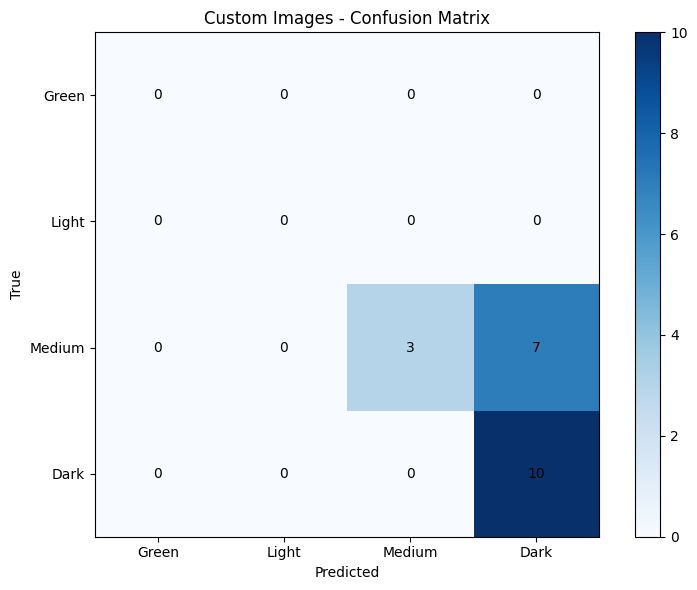

In [8]:
plt.figure(figsize = (8, 6))
plt.imshow(cm, cmap = "Blues")
plt.colorbar()
plt.xticks(range(len(ORDER)), ORDER)
plt.yticks(range(len(ORDER)), ORDER)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Custom Images - Confusion Matrix")
for i in range(len(ORDER)):
    for j in range(len(ORDER)):
        plt.text(j, i, str(cm[i, j]), ha = "center", va = "center")
plt.tight_layout()
plt.show()

### Misclassified Images

Display each misclassified image with its actual and predicted label; list order matches the confusion matrix off-diagonal counts.

Misclassified (actual -> predicted), should match confusion matrix:
  Medium -> Dark: 7


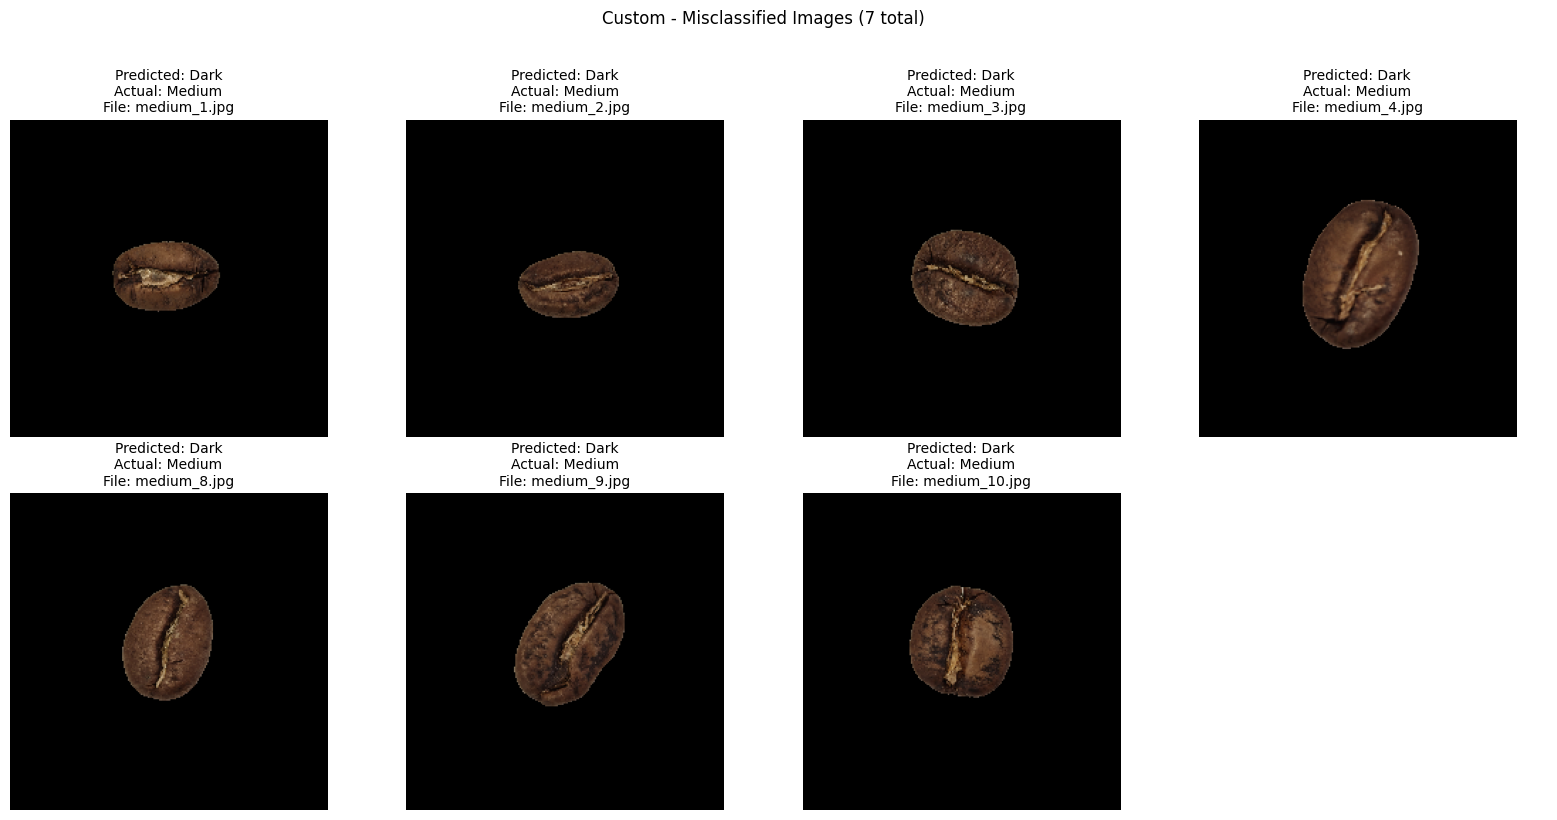

In [9]:
mis_idx = np.where(y_pred_enc != custom_actual_enc)[0]
n_mis = len(mis_idx)
if n_mis == 0:
    print("No misclassified images.")
else:
    mis_pairs = []
    for idx in mis_idx:
        actual = custom_actual[idx]
        pred = y_pred_labels[idx]
        mis_pairs.append((actual, pred))
    mis_counts = Counter(mis_pairs)
    
    print("Misclassified (actual -> predicted), should match confusion matrix:")
    for (a, p), c in sorted(mis_counts.items()):
        print(f"  {a} -> {p}: {c}")
        
    n_cols = 4
    n_rows = int(np.ceil(n_mis / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize = (4 * n_cols, 4 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    for i, idx in enumerate(mis_idx):
        row, col = i // n_cols, i % n_cols
        ax = axes[row, col]
        img_path = paths_custom[idx]
        img = load_image(img_path)
        img = cv2.resize(img, TARGET_SIZE)
        img = remove_background(img)
        actual = custom_actual[idx]
        pred = y_pred_labels[idx]
        ax.imshow(img)
        fname = Path(img_path).name
        ax.set_title(f"Predicted: {pred}\nActual: {actual}\nFile: {fname}", fontsize = 10)
        ax.axis("off")

    for i in range(n_mis, n_rows * n_cols):
        row, col = i // n_cols, i % n_cols
        axes[row, col].axis("off")
    
    plt.suptitle(f"Custom - Misclassified Images ({n_mis} total)", fontsize = 12, y = 1.02)
    plt.tight_layout()
    plt.show()

## Images without Known Labels

Load any images in `custom_test_images` that are **not** listed in `custom_image_labels.csv`, preprocess them the same way, and predict roast level with the trained model. No accuracy metrics are computed; only list (filename -> predicted label) and display the images with their predictions.

Predicted labels for 10 unlabeled image(s):
  unknown_1.jpg  ->  Dark
  unknown_10.jpg  ->  Dark
  unknown_2.jpg  ->  Dark
  unknown_3.jpg  ->  Dark
  unknown_4.jpg  ->  Dark
  unknown_5.jpg  ->  Dark
  unknown_6.jpg  ->  Dark
  unknown_7.jpg  ->  Dark
  unknown_8.jpg  ->  Dark
  unknown_9.jpg  ->  Dark


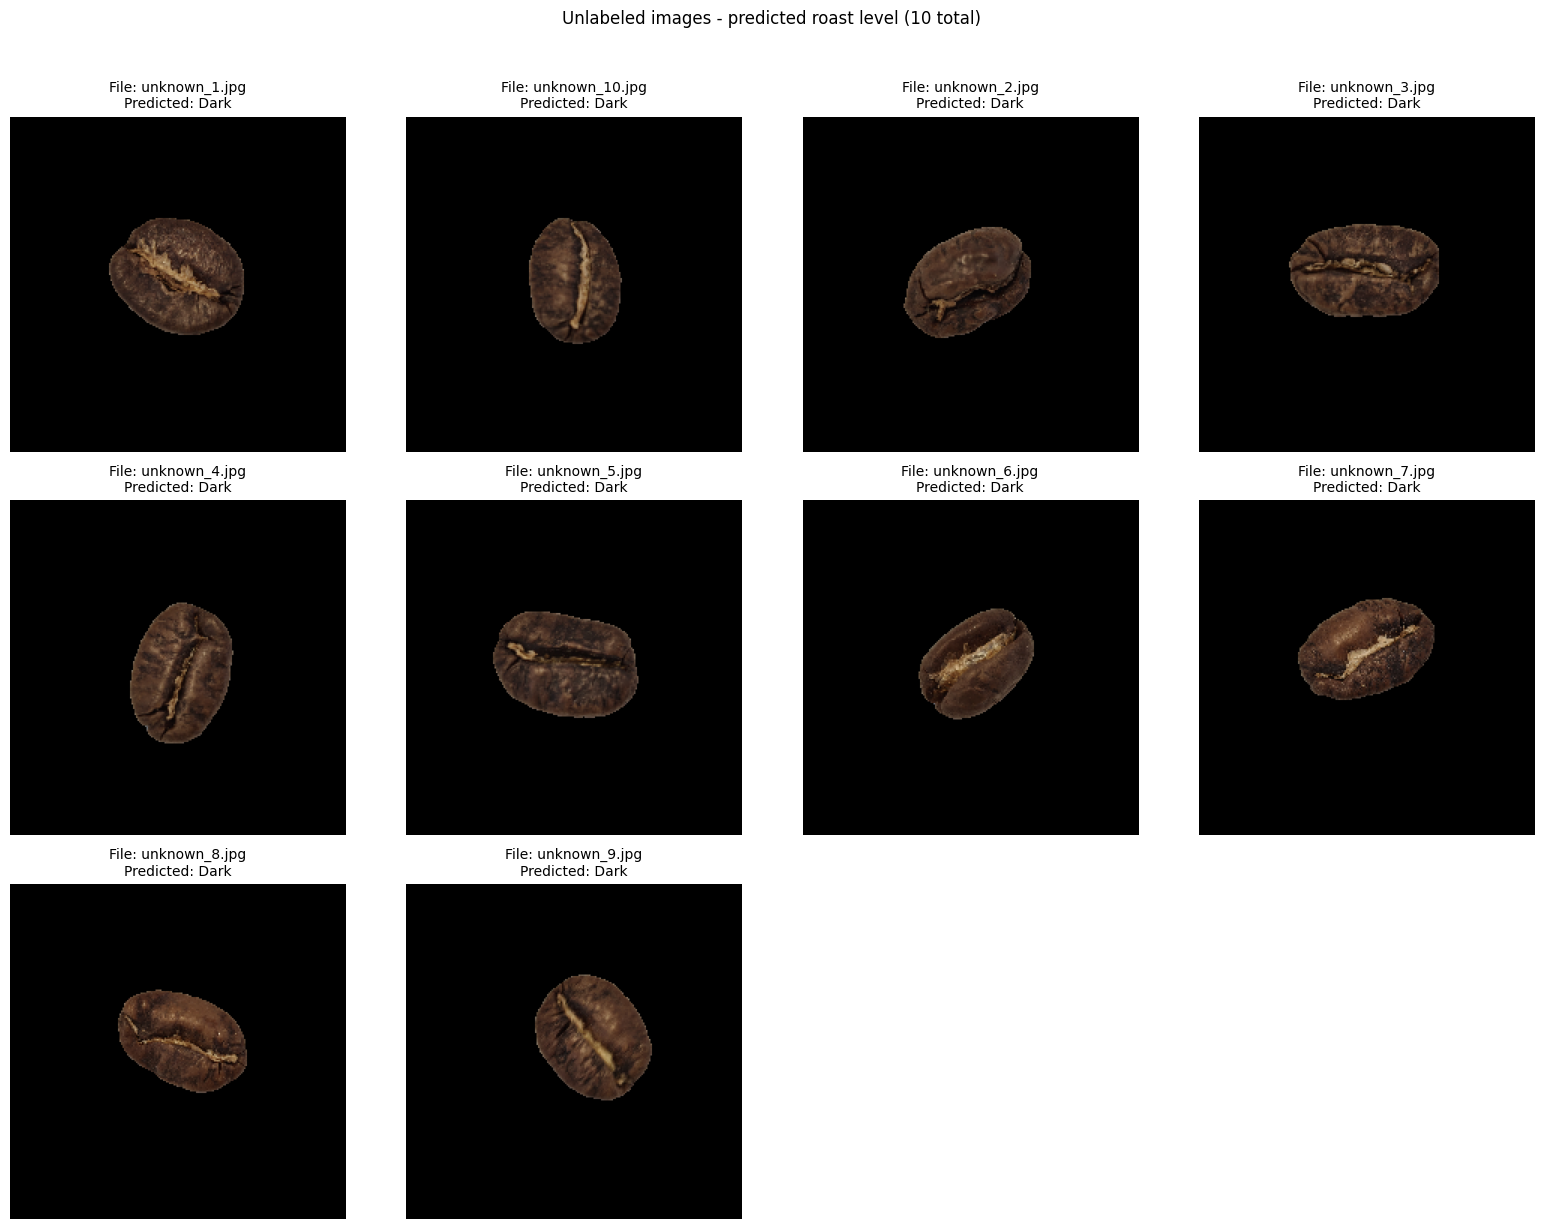

In [10]:
# Image files in folder that are not in the CSV
labeled_filenames = set(labels_df["image_filename"].astype(str))
all_image_files = []
for ext in ("*.png", "*.jpg", "*.jpeg"):
    all_image_files.extend(CUSTOM_IMAGES_DIR.glob(ext))
unlabeled_paths = [p for p in all_image_files if p.name not in labeled_filenames]
unlabeled_paths = sorted(unlabeled_paths, key = lambda p: p.name)

if len(unlabeled_paths) == 0:
    print("No unlabeled images found in custom_test_images (all images are in the CSV).")
else:
    X_unknown = []
    paths_unknown = []
    
    for p in unlabeled_paths:
        img = load_image(p)
        img = cv2.resize(img, TARGET_SIZE)
        img = remove_background(img)
        feat = extract_features(img)
        X_unknown.append(feat)
        paths_unknown.append(str(p))
        
    X_unknown = np.array(X_unknown)
    X_unknown_scaled = scaler.transform(X_unknown)
    y_pred_unknown_enc = rf.predict(X_unknown_scaled)
    y_pred_unknown_labels = le.inverse_transform(y_pred_unknown_enc)

    print(f"Predicted labels for {len(paths_unknown)} unlabeled image(s):")
    for path, pred in zip(paths_unknown, y_pred_unknown_labels):
        print(f"  {Path(path).name}  ->  {pred}")

    n_cols = 4
    n_unk = len(paths_unknown)
    n_rows = int(np.ceil(n_unk / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize = (4 * n_cols, 4 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
        
    for i in range(n_unk):
        row, col = i // n_cols, i % n_cols
        ax = axes[row, col]
        img = load_image(paths_unknown[i])
        img = cv2.resize(img, TARGET_SIZE)
        img = remove_background(img)
        ax.imshow(img)
        ax.set_title(f"File: {Path(paths_unknown[i]).name}\nPredicted: {y_pred_unknown_labels[i]}", fontsize = 10)
        ax.axis("off")

    for i in range(n_unk, n_rows * n_cols):
        row, col = i // n_cols, i % n_cols
        axes[row, col].axis("off")
        
    plt.suptitle(f"Unlabeled images - predicted roast level ({n_unk} total)", fontsize = 12, y = 1.02)
    plt.tight_layout()
    plt.show()